In [1]:
import numpy as np 
import pandas as pd 
import pickle as pkl 
import matplotlib.pyplot as plt  

with open(r'C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\resources\gen_sim_glove_50.pkl', 'rb') as f: 
    glove_vectors = pkl.load(f)

one_attention_weights = pd.read_csv(r'C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\attention_weights\1.2.3_C1_attention_weights.csv')
two_attention_weights = pd.read_csv(r'C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\attention_weights\2.4.1_C1_attention_weights.csv')
three_attention_weights = pd.read_csv(r'C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\attention_weights\3.1.3_C1_attention_weights.csv')

pickle_file = r'C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\preprocessed_features\1.2.3_kinect_sep_09.pkl'
with open(pickle_file, 'rb') as f: 
    data = pkl.load(f)

print(data)

{'skel_post':        J0_dist_from_J1  J0_speed  J0_acceleration  J1_speed  J1_acceleration  \
frame                                                                          
91                 NaN       NaN              NaN       NaN              NaN   
92                 NaN       NaN              NaN       NaN              NaN   
93                 NaN       NaN              NaN       NaN              NaN   
94                 NaN       NaN              NaN       NaN              NaN   
95                 NaN       NaN              NaN       NaN              NaN   
...                ...       ...              ...       ...              ...   
14589        -1.579637  2.877439          2.65342  3.202544         0.001404   
14590        -1.420320  2.877439          2.65342  3.202544         0.001404   
14591        -2.162512  2.877439          2.65342  3.202544         0.001404   
14592        -2.162512  2.877439          2.65342  3.202544         0.001404   
14593        -2.162512  2.

In [13]:
frame_1_one = one_attention_weights[one_attention_weights['frame'] == 1]
print(frame_1_one.head())

emb_dim = glove_vectors['apple'].shape[0]  

average = np.zeros(shape=(1,emb_dim))
for _, row in frame_1_one.iterrows(): 
    r = np.zeros(shape=(1,emb_dim)) 
    cur_word = row['object'].split(' ')
    print(cur_word)
    attention_weight = row['attention_weight'] 
    for word in cur_word: 
        word = ''.join([char for char in word if char.isalpha()]) 
        print("this is the word", word)
        r += glove_vectors[word] #adds both words if there are two in a scene  
    r /= len(cur_word) 
    weighted_emb = r * attention_weight 
    print(weighted_emb)
    average += weighted_emb  
print("this is the average",average/len(frame_1_one))
    
        

# def get_emb(df, emb_dim, attention_weights): 
#     average = np.zeros(shape=(1, emb_dim))
#     for _, row in df.iterrows():
#         r = np.zeros(shape=(1, emb_dim))
#         try:
#             r += glove_vectors[row['name']]
#         except Exception as e:
#             # if object not in glove, split into words
#             words = row['name'].split(' ')
#             for w in words:
#                 w = w.replace('(', '').replace(')', '')
#                 r += glove_vectors[w]
#             r /= len(words)
#         # equal contribution from each object
#         average += r * attention_weights[row['name']] #multiply by the attentional weight here
#     return average / len(df) 


   frame         object  attention_weight
0      1      dumbbell0          0.000001
1      1      dumbbell1          0.000001
2      1          step0          0.000001
3      1        helmet0          0.207972
4      1  spray bottle0          0.172406
['dumbbell0']
this is the word dumbbell
[[-9.10099979e-08  2.25459996e-07 -3.46309994e-07 -5.75919993e-07
   3.17370001e-07  4.45340013e-07  1.63469996e-06  3.23800001e-07
   1.87910008e-07  1.51820006e-07 -5.01749998e-07  3.33750013e-07
   8.18610022e-07  1.11920000e-06 -7.21960017e-07 -4.50620001e-07
  -4.36439996e-07  6.44640036e-07  1.49159999e-07 -5.47230012e-07
   2.87460003e-07 -9.33189999e-07 -1.18840003e-07 -9.08570002e-08
  -3.35550014e-07 -1.49000000e-08  2.45480004e-07  1.14470006e-06
  -1.06330001e-07 -1.07570006e-06 -2.89099995e-07  7.99049983e-07
  -2.33710009e-07  1.28610005e-06  4.38230006e-08  6.17420025e-07
   5.48240012e-07 -1.67550000e-08  1.98379996e-07 -2.85090003e-07
   3.48899994e-07  1.00130000e-07 -6.33520015e-0

: 

Canonical Correlation Analysis 


In [17]:
import cv2 
video_path = r"C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\data\small_videos\2.4.1_C1_trim.mp4"
cap = cv2.VideoCapture(video_path) 

fps = cap.get(cv2.CAP_PROP_FPS) 
print("this is the fps of the video", fps)

this is the fps of the video 59.94005994005994


In [2]:
attention_embs = pd.read_csv(r'C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\scene_embs\2.4.1_C1_scene_vectors.csv')
hand_embs = pd.read_csv(r"C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\scene_embs\2.4.1_kinect_sep_09_nearest_objects_emb.csv")
attention_embs.head()



,frame,attention_1,attention_2,attention_3,attention_4,attention_5,attention_6,attention_7,attention_8,attention_9,...,attention_41,attention_42,attention_43,attention_44,attention_45,attention_46,attention_47,attention_48,attention_49,attention_50
0,1,-0.005352,-0.002383,-0.005312,-0.002397,-0.005830,0.006337,0.003350,-0.002179,0.005894,...,0.006176,-0.004429,-0.002771,0.010208,0.005344,-0.000203,0.009849,0.001540,-0.000114,0.000576
1,2,-0.003093,-0.001655,-0.004537,-0.001065,-0.005465,0.005291,0.002009,-0.001629,0.003608,...,0.003262,-0.003152,-0.001995,0.006082,0.004169,0.000379,0.005248,0.001457,-0.000637,0.001626
2,3,-0.003374,-0.001321,-0.002091,-0.001854,-0.001973,0.002823,0.002115,-0.001139,0.003604,...,0.004174,-0.002168,-0.001411,0.006240,0.002318,-0.000391,0.006377,0.000698,0.000414,-0.000764
3,4,-0.002618,-0.001430,-0.003742,-0.000984,-0.004569,0.004566,0.001754,-0.001428,0.003098,...,0.002799,-0.002534,-0.001664,0.005107,0.003352,0.000427,0.004299,0.001384,-0.000506,0.001278
4,5,-0.008017,-0.003575,-0.006709,-0.000456,-0.003444,0.005533,0.001073,-0.000682,0.002902,...,0.006989,0.000194,-0.004839,0.008462,0.005768,0.000761,0.003893,-0.003125,0.002180,-0.003159


In [3]:
hand_embs.head()
cleaned_hand_embs = hand_embs.dropna(how='any')

fps_hand = 25 
hand_frames = cleaned_hand_embs['frame'].values 
hand_time_stamps = hand_frames/fps_hand 
print(hand_time_stamps)  

cleaned_hand_embs['timestamps_hand'] = cleaned_hand_embs['frame']/25 
cleaned_hand_embs['timestamps_hand']



[  6.6    6.64   6.68 ... 629.44 629.48 629.52]


c:\Users\super\anaconda3\envs\sem-viz-jupyter\lib\site-packages\ipykernel_launcher.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if __name__ == "__main__":


165        6.60
166        6.64
167        6.68
168        6.72
169        6.76
          ...  
15734    629.36
15735    629.40
15736    629.44
15737    629.48
15738    629.52
Name: timestamps_hand, Length: 15574, dtype: float64

In [18]:
attention_embs['timestamps_attention'] = attention_embs['frame']/59.94 
attention_embs['timestamps_attention'].max()


630.0133466800133

In [19]:
tolerance = 0.05
aligned_df = pd.merge_asof(cleaned_hand_embs, attention_embs, left_on='timestamps_hand',
                           right_on = 'timestamps_attention',
                           direction='nearest', tolerance=tolerance)
pd.set_option('display.max_columns',None)
aligned_df.tail(3)
# print(aligned_df['timestamps_hand'])
# print(aligned_df['timestamps_attention'])


,frame_x,objhand_0,objhand_1,objhand_2,objhand_3,objhand_4,objhand_5,objhand_6,objhand_7,objhand_8,objhand_9,objhand_10,objhand_11,objhand_12,objhand_13,objhand_14,objhand_15,objhand_16,objhand_17,objhand_18,objhand_19,objhand_20,objhand_21,objhand_22,objhand_23,objhand_24,objhand_25,objhand_26,objhand_27,objhand_28,objhand_29,objhand_30,objhand_31,objhand_32,objhand_33,objhand_34,objhand_35,objhand_36,objhand_37,objhand_38,objhand_39,objhand_40,objhand_41,objhand_42,objhand_43,objhand_44,objhand_45,objhand_46,objhand_47,objhand_48,objhand_49,timestamps_hand,frame_y,attention_1,attention_2,attention_3,attention_4,attention_5,attention_6,attention_7,attention_8,attention_9,attention_10,attention_11,attention_12,attention_13,attention_14,attention_15,attention_16,attention_17,attention_18,attention_19,attention_20,attention_21,attention_22,attention_23,attention_24,attention_25,attention_26,attention_27,attention_28,attention_29,attention_30,attention_31,attention_32,attention_33,attention_34,attention_35,attention_36,attention_37,attention_38,attention_39,attention_40,attention_41,attention_42,attention_43,attention_44,attention_45,attention_46,attention_47,attention_48,attention_49,attention_50,timestamps_attention
15571,15736,-0.401196,-0.493403,-0.305957,-0.029888,-0.613677,0.499616,0.408470,0.056337,0.536923,0.150312,-0.242431,0.589261,0.387938,0.430901,-0.087843,0.689417,-0.486506,0.500141,0.080693,-1.010806,0.646187,0.211848,0.237066,-0.416715,-0.091522,-0.429282,-0.165139,1.357920,1.016646,-0.422954,-0.024179,0.296409,-0.154323,0.833649,-0.436953,0.796558,0.135611,0.341806,1.122055,-0.177964,0.740448,0.354034,-0.391555,1.161984,-0.114458,0.470071,0.194046,-0.162468,0.291760,-0.569448,629.44,37729,0.464184,-0.476420,-0.155636,0.475046,-1.307117,0.240851,0.631413,0.414577,0.578353,-0.271902,-0.367362,1.260938,0.388009,1.131366,-0.041562,0.790811,-0.954666,1.369702,0.838077,-1.471055,0.612645,-0.054010,-0.250693,-0.113238,0.522312,-0.530535,-0.330594,1.438814,0.928071,-0.351375,0.041047,-0.050930,-0.208431,1.400109,-0.457983,1.239121,-0.024926,0.512887,2.109157,-0.263555,0.667416,0.303431,-0.448499,1.982658,-0.293808,0.458228,0.885137,-0.767807,0.253522,-0.569247,629.446113
15572,15737,-0.403178,-0.493619,-0.306521,-0.031898,-0.613060,0.502000,0.408724,0.054602,0.537865,0.152225,-0.241928,0.588325,0.388618,0.428569,-0.089067,0.689492,-0.485888,0.498711,0.079494,-1.009077,0.646789,0.212470,0.238915,-0.417122,-0.093205,-0.428710,-0.166346,1.357508,1.016491,-0.424481,-0.025644,0.297129,-0.153406,0.831953,-0.435868,0.795639,0.136291,0.340663,1.120212,-0.177569,0.741096,0.353578,-0.391400,1.160843,-0.113948,0.470348,0.193517,-0.159318,0.291461,-0.568987,629.48,37731,0.491587,-0.464864,-0.122161,0.487281,-1.277904,0.207135,0.622432,0.428360,0.553737,-0.248077,-0.372037,1.246574,0.362369,1.155847,-0.025448,0.776342,-0.916152,1.361754,0.792225,-1.481210,0.609857,-0.055984,-0.269878,-0.112414,0.515112,-0.536028,-0.282347,1.443004,0.928307,-0.285193,0.034392,-0.055059,-0.215118,1.371816,-0.440292,1.208682,-0.040417,0.499566,2.060762,-0.255404,0.644694,0.330031,-0.435255,1.948951,-0.332325,0.464003,0.844508,-0.780537,0.258999,-0.580683,629.479479
15573,15738,-0.404561,-0.493776,-0.306934,-0.033055,-0.612511,0.503219,0.408746,0.053654,0.538338,0.153125,-0.241651,0.587636,0.388981,0.427197,-0.089645,0.689541,-0.485532,0.497686,0.078781,-1.008130,0.647094,0.212868,0.240027,-0.417451,-0.094228,-0.428428,-0.166966,1.357348,1.016507,-0.425411,-0.026235,0.297631,-0.152980,0.831076,-0.435482,0.795195,0.136694,0.340172,1.119147,-0.177414,0.741515,0.353340,-0.391358,1.160081,-0.113511,0.470434,0.193111,-0.157663,0.291357,-0.568809,629.52,37733,0.491658,-0.454796,-0.112679,0.486749,-1.255065,0.195627,0.611920,0.427598,0.537867,-0.235383,-0.368976,1.226971,0.350332,1.146887,-0.018922,0.761970,-0.893044,1.342677,0.766187,-1.465084,0.601104,-0.054319,-0.274643,-0.112594,0.508403,-0.530733,-0.258636,1.425067,0.917820,-0.258038,0.031090,-0.054664,-0.

In [23]:
#save to csv 
import os

output_dir = r"C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\scene_embs"
output_path = os.path.join(output_dir, '2.4.1_aligned_hand_attention.csv')
aligned_df.to_csv(output_path, index=False)


Canonical correlations:
Component 1: 0.5742
Component 2: 0.5321
Component 3: 0.4593
Component 4: 0.3157
Component 5: 0.2671
Component 6: 0.2412
Component 7: 0.1677
Component 8: 0.1015
Component 9: 0.0251
Component 10: 0.0183
Component 11: 0.0231
Component 12: 0.0333
Component 13: -0.0495
Component 14: -0.0093
Component 15: -0.0193
Component 16: 0.0236
Component 17: -0.0603
Component 18: -0.0208
Component 19: -0.0149
Component 20: 0.0033
Component 21: -0.0649
Component 22: -0.0362
Component 23: 0.0735
Component 24: 0.0351
Component 25: -0.0941
Component 26: 0.1039
Component 27: 0.0279
Component 28: 0.0631
Component 29: 0.0151
Component 30: 0.0114
Component 31: -0.0276
Component 32: -0.0245
Component 33: -0.0766
Component 34: -0.0366
Component 35: 0.0652
Component 36: 0.0189
Component 37: -0.0257
Component 38: -0.0238
Component 39: -0.0313
Component 40: -0.0151
Component 41: 0.0608
Component 42: -0.0696
Component 43: 0.0006
Component 44: 0.0823
Component 45: -0.0621
Component 46: 0.0023


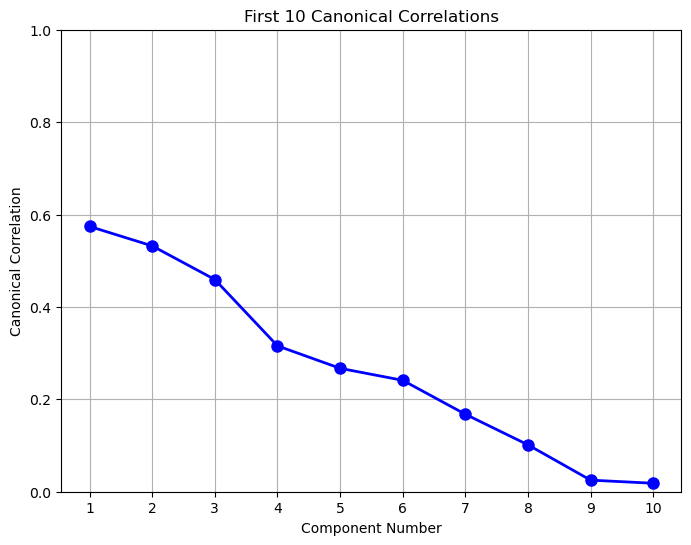

In [27]:
import pandas as pd
import numpy as np
from sklearn.cross_decomposition import CCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Load the CSV file containing the aligned hand and attention data.
df = pd.read_csv(r"C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\scene_embs\2.4.1_aligned_hand_attention.csv")

# Inspect the header if needed
#print(df.columns)

# Extract the objhand and attention columns.
# Here we assume that the objhand columns are those whose names start with "objhand_"
# and the attention columns start with "attention_"
objhand_columns = [col for col in df.columns if col.startswith("objhand_")]
attention_columns = [col for col in df.columns if col.startswith("attention_")]

# Create the X and Y arrays.
X = df[objhand_columns].values      # Shape: (n_frames, 50)
Y = df[attention_columns].values    # Shape: (n_frames, 50)

# Optionally, remove rows with NaN values
mask = np.all(np.isfinite(X), axis=1) & np.all(np.isfinite(Y), axis=1)
X = X[mask]
Y = Y[mask]

# Standardize each set to have zero mean and unit variance.
scaler_X = StandardScaler()
scaler_Y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
Y_scaled = scaler_Y.fit_transform(Y)

# Choose the number of canonical components (up to the minimum of the number of features).
n_components = min(X_scaled.shape[1], Y_scaled.shape[1])

# Initialize and fit CCA. The max_iter is set high to ensure convergence.
cca = CCA(n_components=n_components, max_iter=1000)
cca.fit(X_scaled, Y_scaled)

# Transform the data to obtain the canonical variables.
X_c, Y_c = cca.transform(X_scaled, Y_scaled)

# For each pair of canonical variables, compute the Pearson correlation coefficient.
canonical_corrs = [
    np.corrcoef(X_c[:, i], Y_c[:, i])[0, 1] for i in range(n_components)
]
print("Canonical correlations:")
for i, corr in enumerate(canonical_corrs):
    print(f"Component {i+1}: {corr:.4f}")

# Optionally, visualize the relationship for the first canonical component.
plt.figure(figsize=(8, 6))
components = range(1, 11)  # First 10 components
correlations = canonical_corrs[:10]
plt.plot(components, correlations, 'bo-', linewidth=2, markersize=8)
plt.xlabel("Component Number")
plt.ylabel("Canonical Correlation")
plt.title("First 10 Canonical Correlations")
plt.grid(True)
plt.xticks(components)
plt.ylim(0, 1)  # Correlations are between 0 and 1
plt.show()